# Diyet Problemi - MealPy ile Meta-Sezgisel Optimizasyon Uygulaması

Bu uygulamada klasik **diyet problemi** mühendislikte optimizasyon bakış açısıyla ele alınacaktır.  
Amaç, belirli besin gereksinimlerini sağlayan en düşük maliyetli günlük besin kombinasyonunu bulmaktır.

Bu problemde öğrenciler aşağıdaki kavramları uygulamalı olarak görecektir:

- Karar değişkenlerinin tanımlanması
- Amaç fonksiyonunun kurulması
- Kısıtların ceza fonksiyonu ile ele alınması
- Sürekli karar değişkenleriyle optimizasyon
- Farklı meta-sezgisel algoritmaların karşılaştırılması
- Yakınsama eğrilerinin yorumlanması

# Install MealPy

In [1]:
!pip install mealpy

# Import Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mealpy import FloatVar
from mealpy import GA, PSO, GWO, DE

# Necessary Function

In [3]:
def plot_histories(histories, title="Yakınsama Eğrisi"):
    plt.figure(figsize=(8, 5))
    for name, hist in histories.items():
        plt.plot(hist, label=name)
    plt.xlabel("İterasyon")
    plt.ylabel("En iyi fitness")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def run_optimizers(problem_dict, optimizers):
    results = []
    histories = {}
    solutions = {}

    for name, model in optimizers.items():
        g_best = model.solve(problem_dict)
        best_fit = g_best.target.fitness
        best_sol = g_best.solution

        results.append({
            "Algoritma": name,
            "En İyi Fitness": best_fit,
            "En İyi Çözüm": best_sol
        })

        histories[name] = model.history.list_global_best_fit
        solutions[name] = {
            "best_fitness": best_fit,
            "best_solution": best_sol
        }

        print(f"\n{name}")
        print("-" * len(name))
        print("Best fitness:", best_fit)
        print("Best solution:", best_sol)

    df = pd.DataFrame(results).sort_values("En İyi Fitness").reset_index(drop=True)
    return df, histories, solutions

# Problem: Diyet Problemi

## Problem tanımı

Bir kişinin günlük beslenme ihtiyacını karşılamak için farklı besinlerden kaç porsiyon tüketmesi gerektiğini belirlemek istiyoruz.

Bu problemde amaç, toplam maliyeti en aza indirirken minimum kalori, protein ve kalsiyum gereksinimlerini sağlamaktır.

## Karar değişkenleri

Her besin için porsiyon miktarı karar değişkeni olarak tanımlanır:



$$
x_i = i. \text{ besinden tüketilecek porsiyon miktarı}
$$

Burada $$(x_i)$$ sürekli bir değişkendir ve negatif olamaz.

## Amaç fonksiyonu

$$
\min f(x) = \sum_{i=1}^{n} c_i x_i
$$

Burada \(c_i\), ilgili besinin bir porsiyon maliyetidir.

## Kısıtlar

$$
\sum_{i=1}^{n} Cal_i x_i \geq Cal_{min}
$$

$$
\sum_{i=1}^{n} Pro_i x_i \geq Pro_{min}
$$

$$
\sum_{i=1}^{n} Ca_i x_i \geq Ca_{min}
$$

MealPy ile çalışırken bu kısıtları doğrudan tanımlamak yerine, amaç fonksiyonuna **ceza terimi** ekleyeceğiz.

## Veri setinin tanımlanması

In [4]:
foods = ["Oatmeal", "Chicken", "Eggs", "Milk", "Apple Pie", "Pork"]

cost = np.array([0.30, 2.40, 0.50, 0.60, 1.60, 2.90])
calories = np.array([110, 205, 160, 160, 420, 260])
protein = np.array([4, 32, 13, 8, 4, 14])
calcium = np.array([2, 12, 60, 285, 22, 10])

MIN_CALORIES = 2000
MIN_PROTEIN = 50
MIN_CALCIUM = 800

food_df = pd.DataFrame({
    "Food": foods,
    "Cost": cost,
    "Calories": calories,
    "Protein": protein,
    "Calcium": calcium
})

food_df

,Food,Cost,Calories,Protein,Calcium
0,Oatmeal,0.3,110,4,2
1,Chicken,2.4,205,32,12
2,Eggs,0.5,160,13,60
3,Milk,0.6,160,8,285
4,Apple Pie,1.6,420,4,22
5,Pork,2.9,260,14,10


## Besin verilerinin görselleştirilmesi

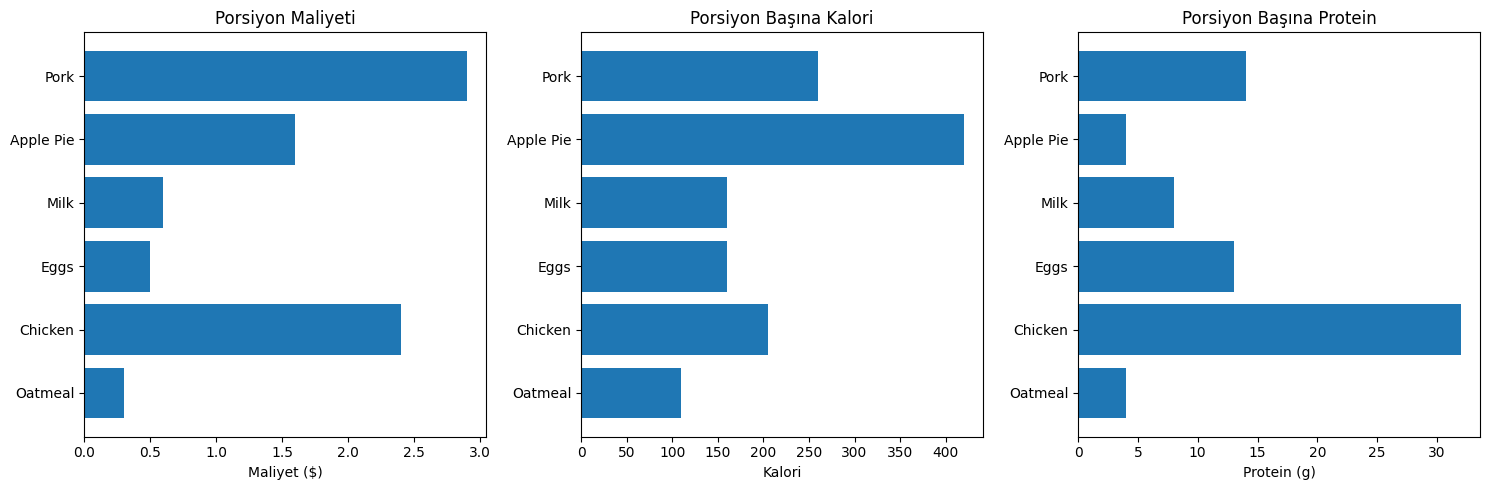

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].barh(food_df["Food"], food_df["Cost"])
axes[0].set_title("Porsiyon Maliyeti")
axes[0].set_xlabel("Maliyet ($)")

axes[1].barh(food_df["Food"], food_df["Calories"])
axes[1].set_title("Porsiyon Başına Kalori")
axes[1].set_xlabel("Kalori")

axes[2].barh(food_df["Food"], food_df["Protein"])
axes[2].set_title("Porsiyon Başına Protein")
axes[2].set_xlabel("Protein (g)")

plt.tight_layout()
plt.show()

In [6]:
# Birim maliyet başına besin değeri
cost_effectiveness_df = pd.DataFrame({
    "Food": foods,
    "Calories_per_Cost": calories / cost,
    "Protein_per_Cost": protein / cost,
    "Calcium_per_Cost": calcium / cost
})

cost_effectiveness_df

,Food,Calories_per_Cost,Protein_per_Cost,Calcium_per_Cost
0,Oatmeal,366.666667,13.333333,6.666667
1,Chicken,85.416667,13.333333,5.000000
2,Eggs,320.000000,26.000000,120.000000
3,Milk,266.666667,13.333333,475.000000
4,Apple Pie,262.500000,2.500000,13.750000
5,Pork,89.655172,4.827586,3.448276


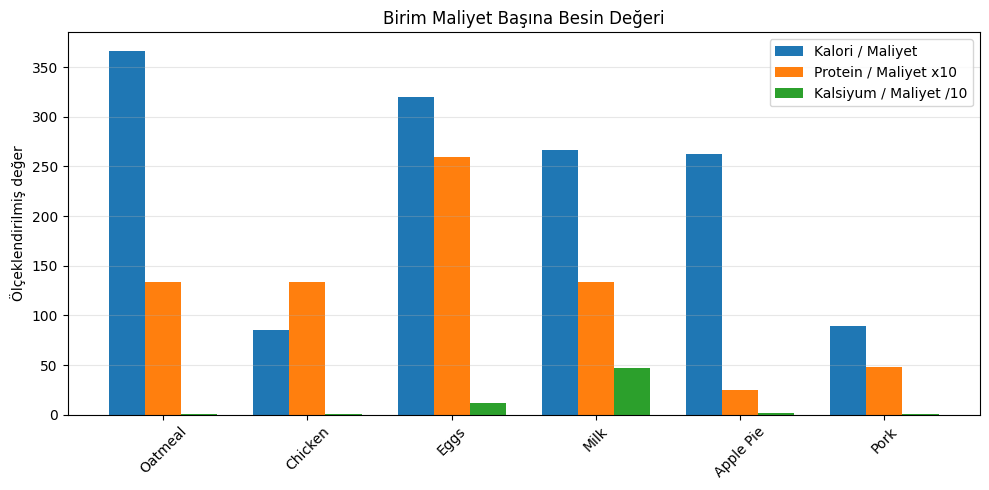

In [7]:
x = np.arange(len(foods))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, cost_effectiveness_df["Calories_per_Cost"], width, label="Kalori / Maliyet")
plt.bar(x, cost_effectiveness_df["Protein_per_Cost"] * 10, width, label="Protein / Maliyet x10")
plt.bar(x + width, cost_effectiveness_df["Calcium_per_Cost"] / 10, width, label="Kalsiyum / Maliyet /10")

plt.xticks(x, foods, rotation=45)
plt.ylabel("Ölçeklendirilmiş değer")
plt.title("Birim Maliyet Başına Besin Değeri")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Amaç fonksiyonunun tanımlanması

Bu problemde algoritmalar toplam maliyeti minimize etmeye çalışacaktır. Ancak çözüm besin gereksinimlerini sağlamazsa ceza uygulanacaktır.

Ceza mantığı şu şekildedir:

- Kalori yetersizse ceza eklenir.
- Protein yetersizse ceza eklenir.
- Kalsiyum yetersizse ceza eklenir.

Bu sayede algoritma yalnızca ucuz değil, aynı zamanda kısıtları sağlayan çözümlere yönlendirilir.

In [8]:
PENALTY_COEFF = 1000

def diet_objective(solution):
    x = np.array(solution)

    total_cost = np.sum(cost * x)
    total_calories = np.sum(calories * x)
    total_protein = np.sum(protein * x)
    total_calcium = np.sum(calcium * x)

    calorie_violation = max(0, MIN_CALORIES - total_calories)
    protein_violation = max(0, MIN_PROTEIN - total_protein)
    calcium_violation = max(0, MIN_CALCIUM - total_calcium)

    # Farklı ölçeklerdeki kısıtları normalize ederek ceza hesaplıyoruz.
    penalty = PENALTY_COEFF * (
        (calorie_violation / MIN_CALORIES) ** 2 +
        (protein_violation / MIN_PROTEIN) ** 2 +
        (calcium_violation / MIN_CALCIUM) ** 2
    )

    fitness = total_cost + penalty
    return fitness

# MealPy problem sözlüğünün oluşturulması

Her karar değişkeni bir besinin porsiyon miktarını göstermektedir.  
Bu uygulamada her besin için porsiyon miktarı 0 ile 10 arasında sınırlandırılmıştır.

In [9]:
n_foods = len(foods)

diet_problem = {
    "bounds": FloatVar(lb=[0] * n_foods, ub=[10] * n_foods, name="servings"),
    "obj_func": diet_objective,
    "minmax": "min",
    "log_to": None
}

# Meta-sezgisel algoritmaların tanımlanması

Bu uygulamada dört farklı meta-sezgisel algoritma kullanılacaktır:

- Genetic Algorithm (GA)
- Particle Swarm Optimization (PSO)
- Grey Wolf Optimizer (GWO)
- Differential Evolution (DE)

In [10]:
diet_optimizers = {
    "GA": GA.BaseGA(epoch=300, pop_size=60),
    "PSO": PSO.OriginalPSO(epoch=300, pop_size=60),
    "GWO": GWO.OriginalGWO(epoch=300, pop_size=60),
    "DE": DE.OriginalDE(epoch=300, pop_size=60)
}

# Algoritmaların çalıştırılması

In [11]:
diet_results, diet_histories, diet_solutions = run_optimizers(diet_problem, diet_optimizers)
diet_results


GA
--
Best fitness: 6.4062826205082475
Best solution: [7.55628426e+00 2.58994944e-02 2.93849321e+00 3.27051294e+00
 3.85467291e-01 6.31246915e-03]

PSO
---
Best fitness: 6.079640292094638
Best solution: [6.99340638e+00 6.23258225e-05 6.20655934e+00 1.45028597e+00
 1.31405385e-07 7.11376795e-09]

GWO
---
Best fitness: 6.002159410198091
Best solution: [1.00000000e+01 1.53880797e-05 3.61146640e+00 1.97584961e+00
 0.00000000e+00 8.19618409e-04]

DE
--
Best fitness: 6.797037758375173
Best solution: [1.27202257e+00 1.91188458e-08 5.53078882e+00 6.04354919e+00
 2.74583274e-06 3.77109017e-03]


,Algoritma,En İyi Fitness,En İyi Çözüm
0,GWO,6.002159,"[10.0, 1.5388079708684537e-05, 3.6114664022789..."
1,PSO,6.079640,"[6.993406382348759, 6.232582247397953e-05, 6.2..."
2,GA,6.406283,"[7.55628426231625, 0.02589949436706096, 2.9384..."
3,DE,6.797038,"[1.2720225724096683, 1.911884579255447e-08, 5...."


# Yakınsama eğrileri

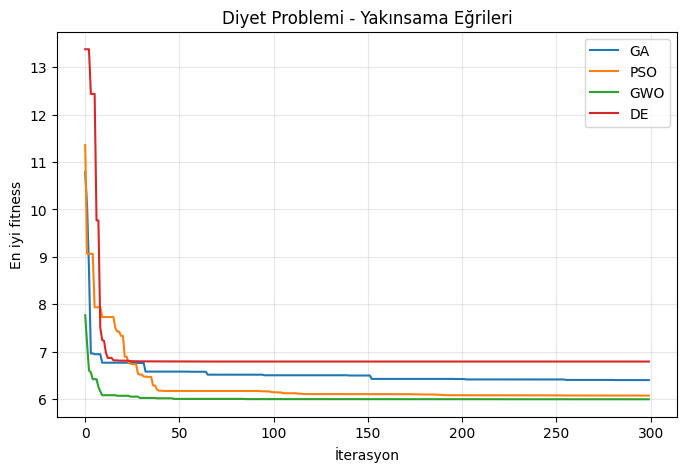

In [12]:
plot_histories(diet_histories, title="Diyet Problemi - Yakınsama Eğrileri")

# En iyi çözümün incelenmesi

In [13]:
best_model_name = diet_results.iloc[0]["Algoritma"]
best_solution = np.array(diet_solutions[best_model_name]["best_solution"])
best_fitness = diet_solutions[best_model_name]["best_fitness"]

print("En iyi algoritma:", best_model_name)
print("En iyi fitness:", best_fitness)
print("En iyi porsiyon değerleri:")
for food, value in zip(foods, best_solution):
    print(f"{food}: {value:.3f}")

En iyi algoritma: GWO
En iyi fitness: 6.002159410198091
En iyi porsiyon değerleri:
Oatmeal: 10.000
Chicken: 0.000
Eggs: 3.611
Milk: 1.976
Apple Pie: 0.000
Pork: 0.001


In [14]:
def analyze_diet_solution(solution):
    x = np.array(solution)

    result_df = pd.DataFrame({
        "Food": foods,
        "Servings": x,
        "Cost": cost * x,
        "Calories": calories * x,
        "Protein": protein * x,
        "Calcium": calcium * x
    })

    totals = {
        "Total Cost": np.sum(cost * x),
        "Total Calories": np.sum(calories * x),
        "Total Protein": np.sum(protein * x),
        "Total Calcium": np.sum(calcium * x)
    }

    return result_df, totals


best_diet_df, best_totals = analyze_diet_solution(best_solution)

display(best_diet_df.round(3))

print("Toplam maliyet:", round(best_totals["Total Cost"], 3))
print("Toplam kalori:", round(best_totals["Total Calories"], 3), "/", MIN_CALORIES)
print("Toplam protein:", round(best_totals["Total Protein"], 3), "/", MIN_PROTEIN)
print("Toplam kalsiyum:", round(best_totals["Total Calcium"], 3), "/", MIN_CALCIUM)

,Food,Servings,Cost,Calories,Protein,Calcium
0,Oatmeal,10.000,3.000,1100.000,40.000,20.000
1,Chicken,0.000,0.000,0.003,0.000,0.000
2,Eggs,3.611,1.806,577.835,46.949,216.688
3,Milk,1.976,1.186,316.136,15.807,563.117
4,Apple Pie,0.000,0.000,0.000,0.000,0.000
5,Pork,0.001,0.002,0.213,0.011,0.008


Toplam maliyet: 5.994
Toplam kalori: 1994.187 / 2000
Toplam protein: 102.768 / 50
Toplam kalsiyum: 799.814 / 800


# Algoritmaların detaylı karşılaştırılması

Sadece fitness değerini karşılaştırmak yeterli değildir.  
Her algoritmanın bulduğu çözümün maliyeti ve kısıtları ne kadar sağladığı da incelenmelidir.

In [15]:
comparison_rows = []

for name, sol_data in diet_solutions.items():
    sol = sol_data["best_solution"]
    sol_df, totals = analyze_diet_solution(sol)

    comparison_rows.append({
        "Algoritma": name,
        "Fitness": sol_data["best_fitness"],
        "Toplam Maliyet": totals["Total Cost"],
        "Kalori": totals["Total Calories"],
        "Protein": totals["Total Protein"],
        "Kalsiyum": totals["Total Calcium"],
        "Kalori Sağlandı mı?": totals["Total Calories"] >= MIN_CALORIES,
        "Protein Sağlandı mı?": totals["Total Protein"] >= MIN_PROTEIN,
        "Kalsiyum Sağlandı mı?": totals["Total Calcium"] >= MIN_CALCIUM
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("Fitness").reset_index(drop=True)
comparison_df.round(3)

,Algoritma,Fitness,Toplam Maliyet,Kalori,Protein,Kalsiyum,Kalori Sağlandı mı?,Protein Sağlandı mı?,Kalsiyum Sağlandı mı?
0,GWO,6.002,5.994,1994.187,102.768,799.814,False,True,False
1,PSO,6.080,6.072,1994.383,120.263,799.713,False,True,False
2,GA,6.406,6.396,1993.479,97.049,1132.373,False,True,True
3,DE,6.797,6.784,1992.798,125.390,2056.841,False,True,True


# En iyi diyet planının görselleştirilmesi

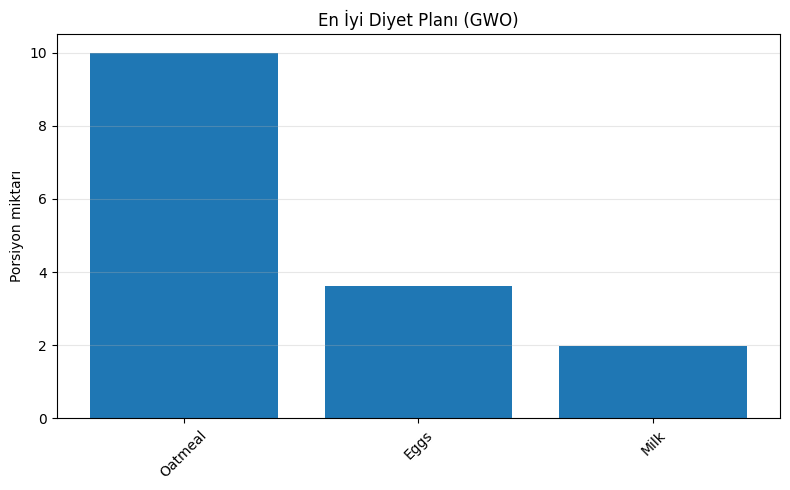

In [16]:
nonzero_df = best_diet_df[best_diet_df["Servings"] > 0.01].copy()

plt.figure(figsize=(8, 5))
plt.bar(nonzero_df["Food"], nonzero_df["Servings"])
plt.ylabel("Porsiyon miktarı")
plt.title(f"En İyi Diyet Planı ({best_model_name})")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

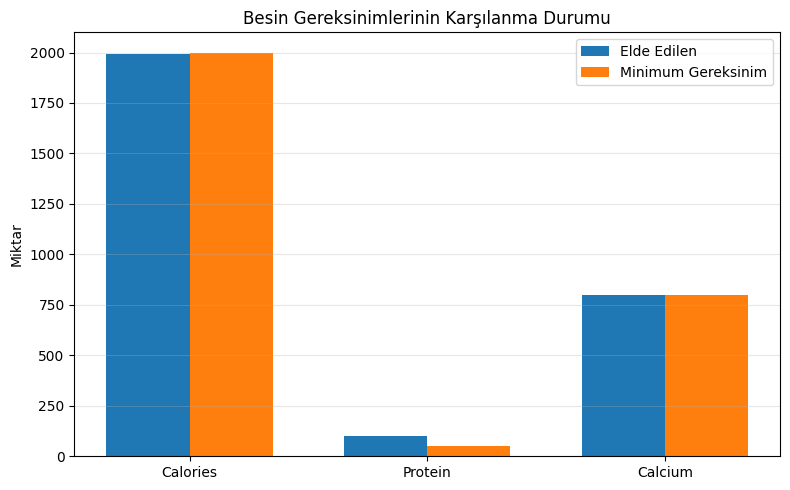

In [17]:
nutrient_names = ["Calories", "Protein", "Calcium"]
achieved = [
    best_totals["Total Calories"],
    best_totals["Total Protein"],
    best_totals["Total Calcium"]
]
required = [MIN_CALORIES, MIN_PROTEIN, MIN_CALCIUM]

x = np.arange(len(nutrient_names))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, achieved, width, label="Elde Edilen")
plt.bar(x + width / 2, required, width, label="Minimum Gereksinim")

plt.xticks(x, nutrient_names)
plt.ylabel("Miktar")
plt.title("Besin Gereksinimlerinin Karşılanma Durumu")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

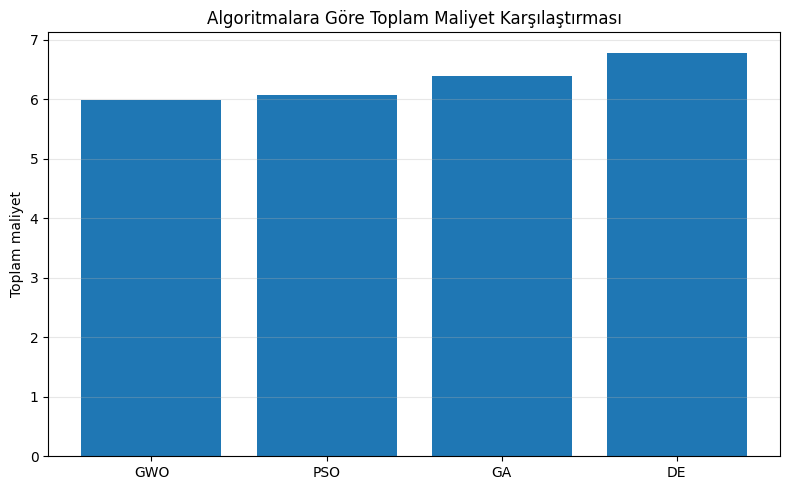

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Algoritma"], comparison_df["Toplam Maliyet"])
plt.ylabel("Toplam maliyet")
plt.title("Algoritmalara Göre Toplam Maliyet Karşılaştırması")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Sonuçların yorumlanması

Bu uygulamada diyet problemi, sürekli karar değişkenlerine sahip kısıtlı bir optimizasyon problemi olarak ele alınmıştır.  
MealPy doğrudan kısıt tanımlamak yerine amaç fonksiyonu üzerinden çalıştığı için, besin gereksinimleri ceza fonksiyonu yardımıyla modele dahil edilmiştir.

Öğrenciler bu örnek üzerinden şu çıkarımları yapabilir:

- Karar değişkenleri, her besinden kaç porsiyon tüketileceğini temsil eder.
- Amaç fonksiyonu toplam maliyeti minimize eder.
- Kısıtlar doğrudan değil, ceza yaklaşımıyla temsil edilir.
- Farklı meta-sezgisel algoritmalar aynı problemi farklı yakınsama davranışlarıyla çözebilir.
- En düşük fitness değeri yalnızca maliyeti değil, kısıt ihlallerini de içerdiği için dikkatli yorumlanmalıdır.

# Öğrenci alıştırmaları

1. Her besin için maksimum porsiyon sınırını 5 olarak değiştiriniz.
2. Minimum protein ihtiyacını 70 g yaparak algoritmaları yeniden çalıştırınız.
3. Ceza katsayısını 100, 1000 ve 10000 olarak değiştirip sonuçları karşılaştırınız.
4. Yeni bir besin ekleyiniz ve optimum diyet planının değişip değişmediğini inceleyiniz.
5. Çözümde en az üç farklı besinin kullanılmasını sağlayacak yeni bir ceza terimi yazınız.